## LLP133 Case Study — Credit Risk Prediction
#### ***How effectively can financial data predict loan default, and which features drive risk?***

---

**Dataset:** [Credit Risk Dataset — Kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)
**Target Variable:** 'loan_status' (0= = non-default, 1 = default)

| Column | Description |
|---|---|
| person_age | Age |
| person_income | Annual income |
| person_home_ownership | Home ownership status |
| person_emp_length | Employment length (years) |
| loan_intent | Purpose of loan |
| loan_grade | Lender-assigned risk grade |
| loan_amnt | Loan amount requested |
| loan_int_rate | Interest rate |
| loan_status | Target — 0: non-default, 1: default |
| loan_percent_income | Loan amount as % of income |
| cb_person_default_on_file | Historical default on record |
| cb_person_cred_hist_length | Credit history length (years) |

---

### Section 0 — Setup
- 0.1 Business Context
- 0.2 Imports

### Section 1 — Data Preparation
- 1.1 Initial Inspection
- 1.2 Data Quality Assessment
- 1.3 Cleaning & Preprocessing

### Section 2 — Exploratory Analysis
- 2.1 Univariate Analysis
- 2.2 Bivariate Analysis
- 2.3 Correlation Analysis
- 2.4 Key Insights

### Section 3 — Feature Engineering
- 3.1 Encoding & Scaling

### Section 4 — Model Development
- 4.1 Train / Test Split
- 4.2 Baseline — Logistic Regression
- 4.3 XGBoost Classifier
- 4.4 Hyperparameter Tuning

### Section 5 — Model Evaluation
- 5.1 Metrics (F1, ROC-AUC, Precision, Recall)
- 5.2 Confusion Matrix
- 5.3 Model Comparison

### Section 6 — Business Recommendations

---

### Section 0 — Setup


#### 0.1 Business Context

Credit default is a key driver of financial risk in retail lending, directly impacting profitability and capital allocation. Improving the accuracy of default prediction enables lenders to optimise approval strategies and reduce expected losses.

This project uses historical applicant data to build models that predict credit default and identify the factors that drive creditworthiness. Better prediction supports more informed lending decisions and reduces expected losses.

**Business Question:** How effectively can applicant financial data predict loan default, and which features should inform lending decisions?

#### 0.2 Imports

In [1]:
#Data Manipulation Libraries 
import numpy as np
import pandas as pd 

#Data Visualisation Libraries
import matplotlib.pyplot as plt 
import seaborn as sns
plt.style.use('seaborn-v0_8')
sns.set_theme()

#Machine Learning Libraries  
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

#Machine Learning Evaluation Libraries 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
)

from sklearn.metrics import (
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

#Misc:
import warnings
warnings.filterwarnings('ignore')

### Section 1 — Data Preparation

#### 1.1 Initial Inspection

In [2]:
credit_df = pd.read_csv("data/credit_risk_dataset.csv")

In [3]:
credit_df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
credit_df.sample(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
30573,48,32000,RENT,4.0,MEDICAL,A,8000,6.62,0,0.25,N,14
30966,42,72000,MORTGAGE,20.0,HOMEIMPROVEMENT,A,8400,6.62,0,0.12,N,11
21201,30,45600,MORTGAGE,5.0,HOMEIMPROVEMENT,A,5000,7.29,0,0.11,N,8
22829,30,58239,MORTGAGE,3.0,VENTURE,A,10500,6.62,0,0.18,N,5
7996,22,27600,RENT,7.0,MEDICAL,B,7200,10.59,0,0.26,N,3


In [5]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
credit_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


#### 1.2 Data Quality Assessment


In [7]:
#Checking amount of null values found in each row
for col in credit_df.columns:
    null_values = credit_df[col].isnull().sum()
    print(f'{col}: {null_values} missing values')

person_age: 0 missing values
person_income: 0 missing values
person_home_ownership: 0 missing values
person_emp_length: 895 missing values
loan_intent: 0 missing values
loan_grade: 0 missing values
loan_amnt: 0 missing values
loan_int_rate: 3116 missing values
loan_status: 0 missing values
loan_percent_income: 0 missing values
cb_person_default_on_file: 0 missing values
cb_person_cred_hist_length: 0 missing values


In [8]:
#Check for duplicate rows
print(f"Duplicate rows: {credit_df.duplicated().sum()}")

Duplicate rows: 165


In [9]:
#Check for amount of unique values per column
for col in credit_df.columns:
    unique_values = credit_df[col].nunique()
    print(f'{col}: {unique_values} unique values') 

person_age: 58 unique values
person_income: 4295 unique values
person_home_ownership: 4 unique values
person_emp_length: 36 unique values
loan_intent: 6 unique values
loan_grade: 7 unique values
loan_amnt: 753 unique values
loan_int_rate: 348 unique values
loan_status: 2 unique values
loan_percent_income: 77 unique values
cb_person_default_on_file: 2 unique values
cb_person_cred_hist_length: 29 unique values


In [10]:
credit_df['person_age'].unique()

array([ 22,  21,  25,  23,  24,  26, 144, 123,  20,  32,  34,  29,  33,
        28,  35,  31,  27,  30,  36,  40,  50,  45,  37,  39,  44,  43,
        41,  46,  38,  47,  42,  48,  49,  58,  65,  51,  53,  66,  61,
        54,  57,  59,  62,  60,  55,  52,  64,  70,  78,  69,  56,  73,
        63,  94,  80,  84,  76,  67])

In [11]:
credit_df['person_income'].unique()

array([  59000,    9600,   65500, ...,  720000, 1900000,    4888])

In [12]:
credit_df['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [13]:
credit_df['person_emp_length'].unique()

array([123.,   5.,   1.,   4.,   8.,   2.,   6.,   7.,   0.,   9.,   3.,
        10.,  nan,  11.,  18.,  12.,  17.,  14.,  16.,  13.,  19.,  15.,
        20.,  22.,  21.,  24.,  23.,  26.,  25.,  27.,  28.,  31.,  41.,
        34.,  29.,  38.,  30.])

In [14]:
credit_df['loan_grade'].unique()

array(['D', 'B', 'C', 'A', 'E', 'F', 'G'], dtype=object)

In [15]:
print(credit_df['cb_person_default_on_file'].unique())

['Y' 'N']


In [17]:
credit_df['cb_person_cred_hist_length'].unique()

array([ 3,  2,  4,  8,  7,  6,  9, 10,  5, 11, 16, 15, 12, 13, 17, 14, 25,
       28, 27, 22, 19, 29, 23, 26, 20, 21, 30, 24, 18])

In [18]:
#Assessing outliers in columns 
for col in credit_df.columns:
    if credit_df[col].dtype in ['int64', 'float64']:
        q1 = credit_df[col].quantile(0.25)
        q3 = credit_df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = credit_df[(credit_df[col] < lower_bound) | (credit_df[col] > upper_bound)]
        print(f'{col}: {len(outliers)} outliers')

person_age: 1494 outliers
person_income: 1484 outliers
person_emp_length: 853 outliers
loan_amnt: 1689 outliers
loan_int_rate: 6 outliers
loan_status: 7108 outliers
loan_percent_income: 651 outliers
cb_person_cred_hist_length: 1142 outliers


#### 1.3 Cleaning & Preprocessing

In [19]:
#Remove Duplicate rows
credit_df = credit_df.drop_duplicates()
print(f"Duplicate rows: {credit_df.duplicated().sum()}")

Duplicate rows: 0


In [20]:
#Remove extreme age values (e.g. 144)
credit_df = credit_df[~((credit_df['person_age'] < 18) | 
                        (credit_df['person_age'] > 85))]

In [21]:
#Remove erroneous and null employment lengths
credit_df = credit_df.dropna(subset=['person_emp_length'])
credit_df = credit_df[credit_df['person_emp_length'] < 100]

In [22]:
#Removing null interest rates rows 
credit_df = credit_df.dropna(subset=['loan_int_rate'])

In [23]:
#Capping income to mitigate right skew 
income_cap = credit_df['person_income'].quantile(0.99)
credit_df['person_income'] = credit_df['person_income'].clip(upper=income_cap)

In [24]:
#Confirm clean by checking nulls and final shape
print(credit_df.isnull().sum())
print(f"\nFinal shape: {credit_df.shape}")

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Final shape: (28495, 12)


## Section 2 — Exploratory Data Analysis

#### 2.1 Univariate Analysis

Examining the distribution of key variables to understand the structure of the dataset, identify potential outliers, and help inform preprocessing decisions.

Key variables analysed include:
- Applicant financials (income, loan amount, loan percent income)
- Credit indicators (credit history length, loan grade)
- Applicant characteristics (employment length, loan intent)
- Target variable (loan status)

##### Applicant Financials

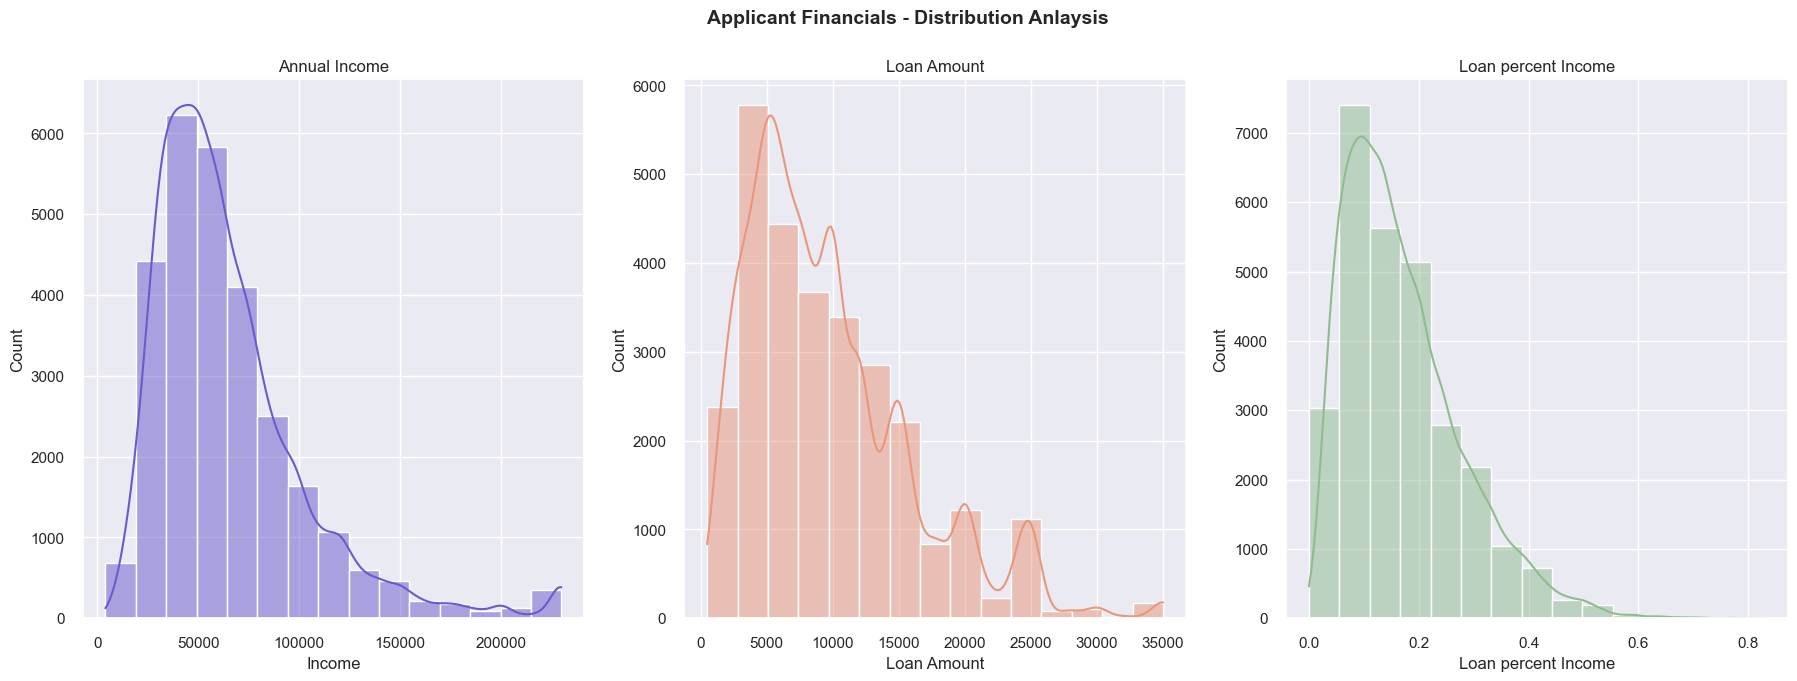

In [25]:
fig, axes = plt.subplots(1,3, figsize= (22,7))
fig.suptitle('Applicant Financials - Distribution Anlaysis', fontsize= 14, fontweight= 'bold')

#Persons Income Distribution 
sns.histplot(
    x= credit_df['person_income'],
    bins= 15,
    kde= True,
    ax= axes[0],
    color= 'slateblue'
)
axes[0].set_title("Annual Income")
axes[0].set_xlabel("Income")

#Loan Amount Distribution
sns.histplot(
    x= credit_df['loan_amnt'],
    bins= 15,
    kde= True,
    ax= axes[1],
    color= 'darksalmon'
)
axes[1].set_title("Loan Amount")
axes[1].set_xlabel("Loan Amount")

#Loan Percent Income Distribution
sns.histplot(
    x= credit_df['loan_percent_income'],
    bins= 15,
    kde= True,
    ax = axes[2],
    color= 'darkseagreen'
)
axes[2].set_title("Loan percent Income")
axes[2].set_xlabel("Loan percent Income")

#plt.tight_layout()
plt.show()

Note: Highly skewed distribution for Annual Income which would require further preprocessing to manage range of incomes in the data 

##### Credit indicators 

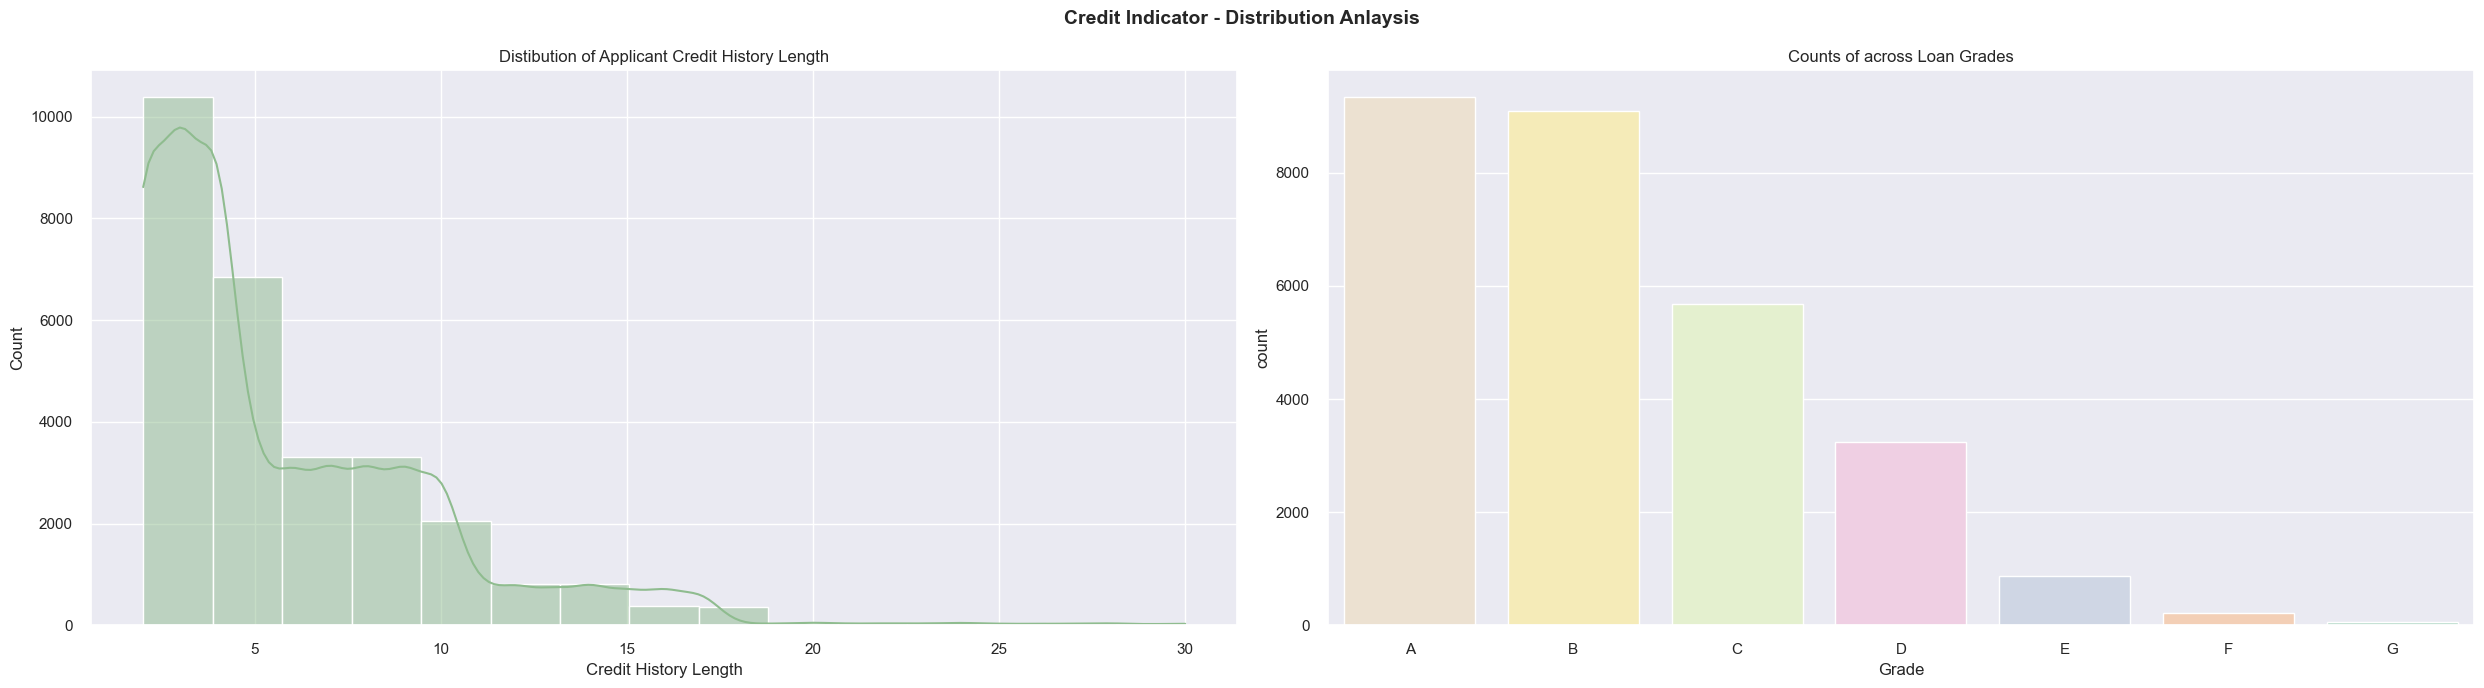

In [26]:
fig, axes = plt.subplots(1,2,figsize=(25,7))
fig.suptitle('Credit Indicator - Distribution Anlaysis', fontsize= 14, fontweight= 'bold')

#Distiribution of credit history length 
sns.histplot(
    x= credit_df['cb_person_cred_hist_length'],
    bins= 15,
    kde= True,
    ax= axes[0],
    color= 'darkseagreen'
)
axes[0].set_title("Distibution of Applicant Credit History Length")
axes[0].set_xlabel("Credit History Length")

#Proportions across different Loan Grades 
sns.countplot(
    x= credit_df['loan_grade'],
    order=credit_df['loan_grade'].value_counts().index,
    ax= axes[1],
    palette= 'Pastel2_r'
)
axes[1].set_title("Counts of across Loan Grades")
axes[1].set_xlabel("Grade")

plt.tight_layout()
plt.show()

##### Applicant Characteristics

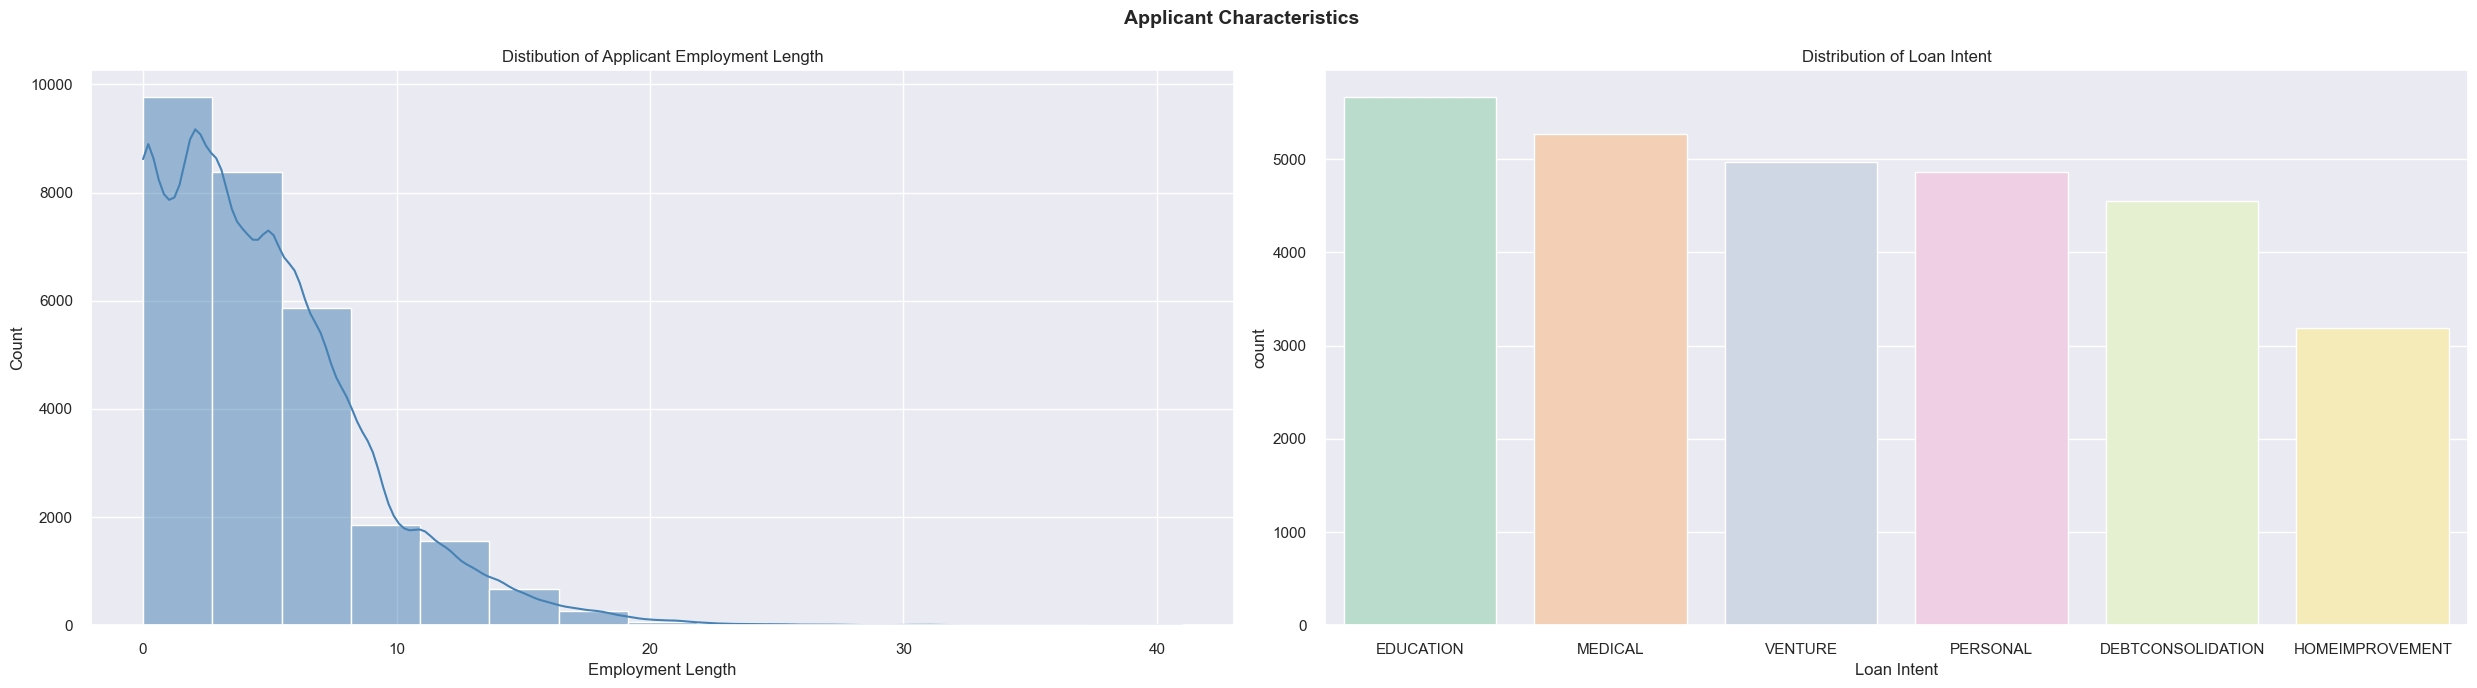

In [27]:
fig, axes = plt.subplots(1,2,figsize=(25,7))
fig.suptitle('Applicant Characteristics', fontsize= 14, fontweight= 'bold')

#Distiribution of applicant employment length 
sns.histplot(
    x= credit_df['person_emp_length'],
    bins= 15,
    kde= True,
    ax= axes[0],
    color= 'steelblue'
)
axes[0].set_title("Distibution of Applicant Employment Length")
axes[0].set_xlabel("Employment Length")

#Distribution across different reasons behind an applicnats loan request
sns.countplot(
    x= credit_df['loan_intent'],
    order=credit_df['loan_intent'].value_counts().index,
    ax= axes[1],
    palette= 'Pastel2'
)
axes[1].set_title("Distribution of Loan Intent")
axes[1].set_xlabel("Loan Intent")

plt.tight_layout()
plt.show()

##### Target Variable Analysis

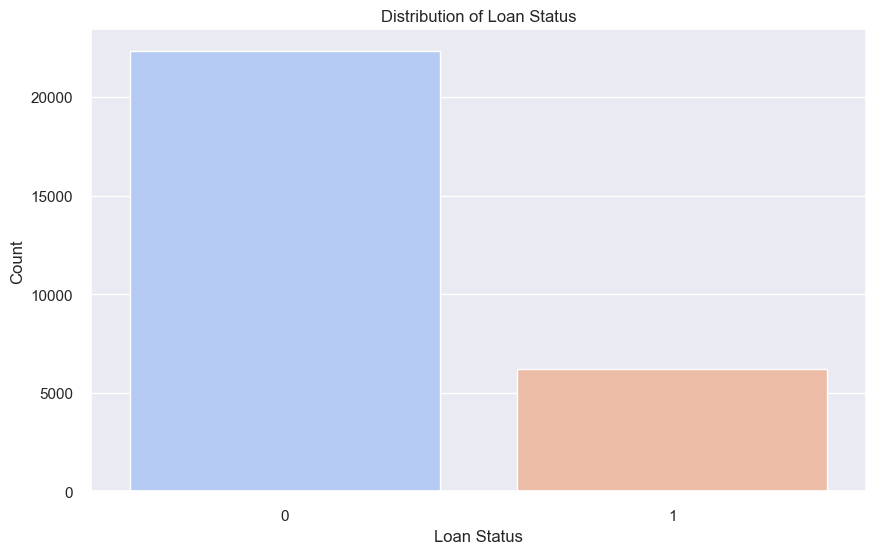

In [28]:
# Visualize the count of loan defaults and non-defaults
plt.figure(figsize=(10, 6))
sns.countplot(
    data=credit_df,
    x='loan_status',
    palette='coolwarm',
    order=credit_df['loan_status'].value_counts().index)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

_Note: Initial univariate EDA was performed on the raw dataset to identify skewness, outliers, and missingness. These insights informed the preprocessing steps. After cleaning, the univariate plots were re‑run to ensure the distributions reflected realistic values._

#### 2.2 Bivariate Analysis

Examining the relationship between key features and the target variable (loan default), with the goal of identifying factors that are most predictive of credit risk.

Key relationships analysed include:
- Financial factors vs default (income, loan amount, loan percent income)
- Credit indicators vs default (credit history length, credit default history, loan grade)
- Applicant characteristics vs default (employment length, loan intent)
- Target Correlations

##### Applicant Financial Factors vs Loan Default

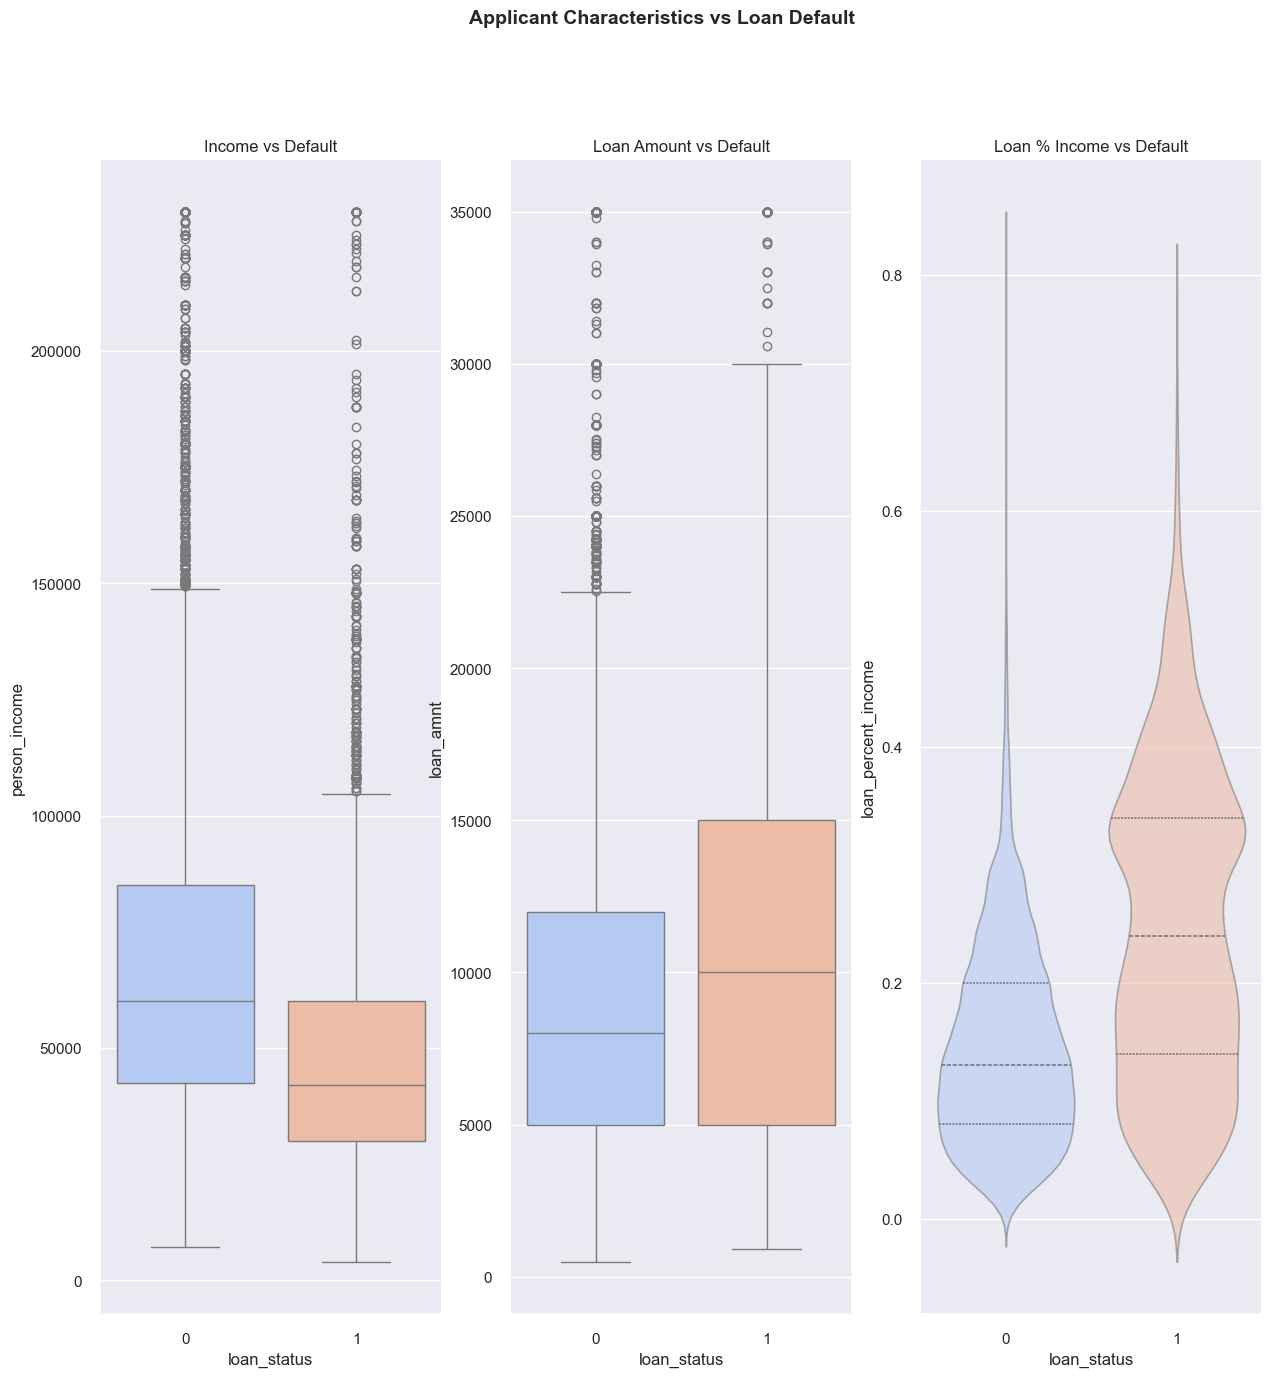

In [67]:
fig, axes = plt.subplots(1,3, figsize= (15,15))
fig.suptitle('Applicant Characteristics vs Loan Default', fontsize= 14, fontweight= 'bold')

#Boxplot showing Distribution of Income across people who defaulted and did not 
sns.boxplot(
    data= credit_df,
    x= 'loan_status',
    y= 'person_income',
    ax= axes[0],
    palette= 'coolwarm'
)
axes[0].set_title('Income vs Default')

#Boxplot showing Distribution of Loan amount across people who defaulted and did not 
sns.boxplot(
    data= credit_df,
    x= 'loan_status',
    y= 'loan_amnt',
    ax= axes[1],
    palette= 'coolwarm'
)
axes[1].set_title('Loan Amount vs Default')

#Violin showing Distribution of Loan % Income across people who defaulted and did not 
sns.violinplot(
    data=credit_df,
    x='loan_status',
    y='loan_percent_income',
    ax=axes[2],
    palette='coolwarm',
    inner= 'quartile',
    linewidth=1.2,
    alpha=0.6
)

axes[2].set_title('Loan % Income vs Default')

plt.show()

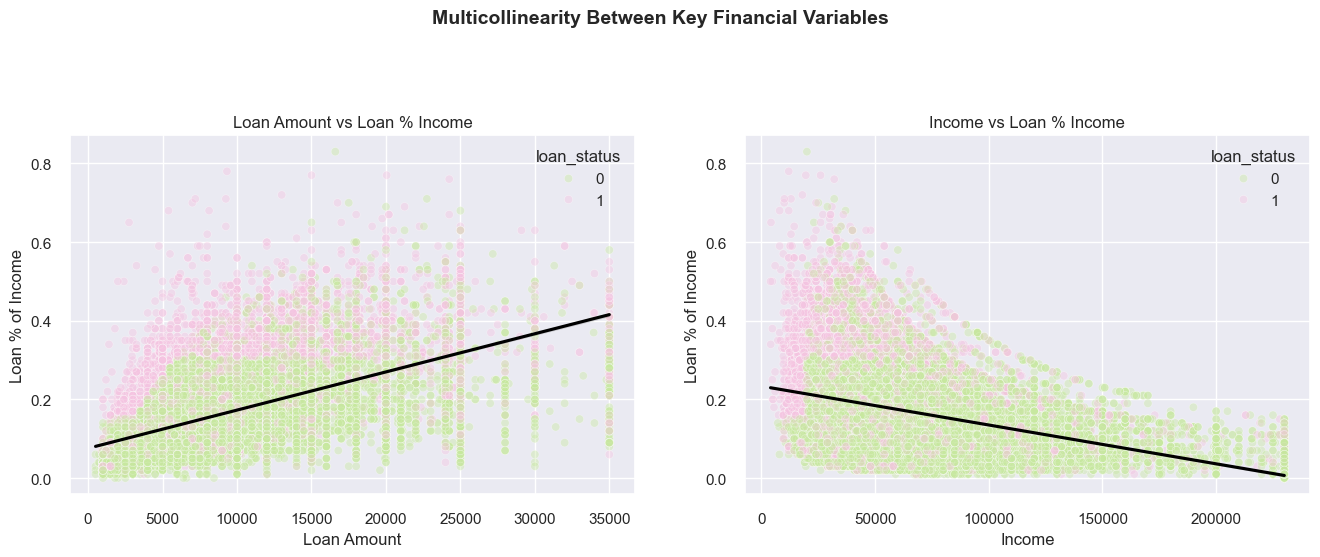

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Multicollinearity Between Key Financial Variables", fontsize=14, fontweight='bold')

# 1. Loan Amount vs Loan % Income
sns.scatterplot(
    data=credit_df,
    x='loan_amnt',
    y='loan_percent_income',
    hue='loan_status',
    palette='PiYG_r',
    alpha=0.4,
    ax=axes[0]
)
sns.regplot(
    data=credit_df,
    x='loan_amnt',
    y='loan_percent_income',
    scatter=False,
    color='black',
    ax=axes[0]
)
axes[0].set_title("Loan Amount vs Loan % Income")
axes[0].set_xlabel("Loan Amount")
axes[0].set_ylabel("Loan % of Income")

# 2. Income vs Loan % Income
sns.scatterplot(
    data=credit_df,
    x='person_income',
    y='loan_percent_income',
    hue='loan_status',
    palette='PiYG_r',
    alpha=0.4,
    ax=axes[1]
)
sns.regplot(
    data=credit_df,
    x='person_income',
    y='loan_percent_income',
    scatter=False,
    color='black',
    ax=axes[1]
)
axes[1].set_title("Income vs Loan % Income")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Loan % of Income")

plt.tight_layout(pad=3)
plt.show()


##### Credit Indicators vs Loan Default

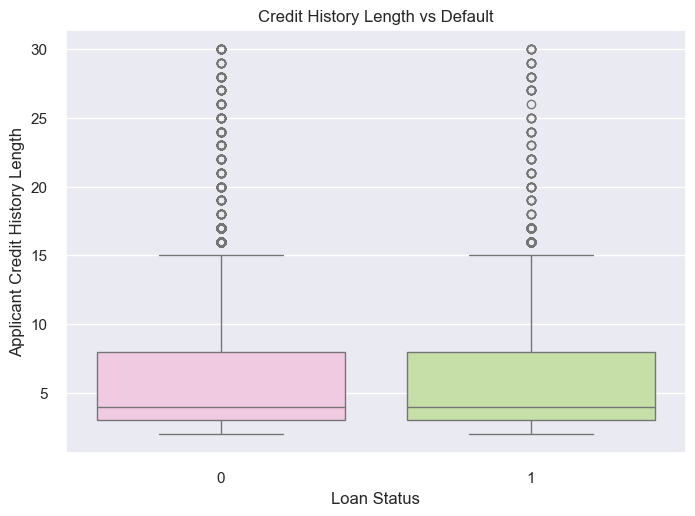

In [31]:
sns.boxplot(
    data= credit_df,
    x= 'loan_status',
    y= 'cb_person_cred_hist_length',
    palette= 'PiYG'
)
plt.title('Credit History Length vs Default')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Credit History Length')
plt.show()

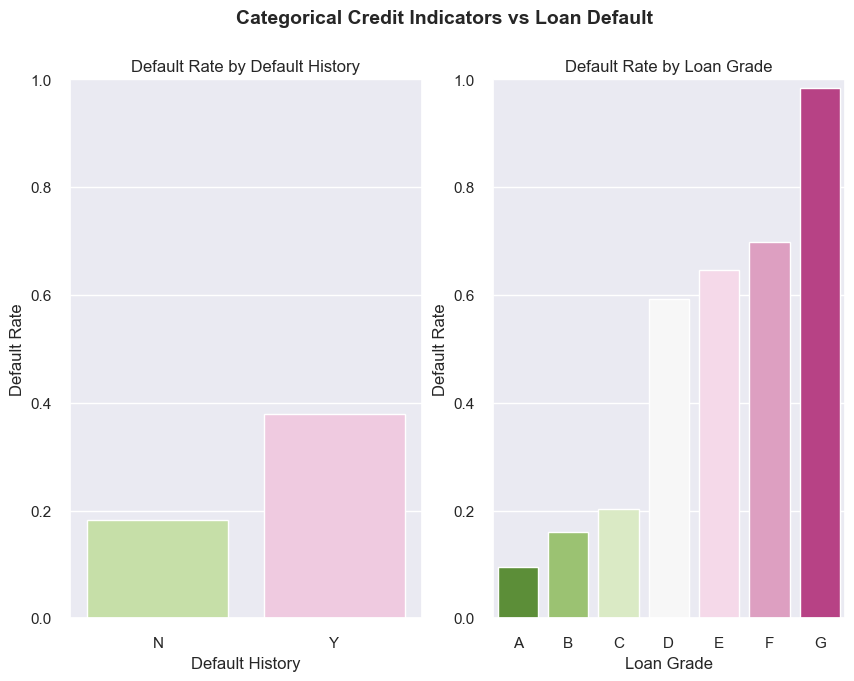

In [32]:
fig,axes = plt.subplots(1,2, figsize= (10,7))
fig.suptitle('Categorical Credit Indicators vs Loan Default', fontsize= 14, fontweight= 'bold')

default_rate = (credit_df.groupby("cb_person_default_on_file")["loan_status"].mean().rename("default_rate"))
default_rate = default_rate.reset_index()

#probability of default differs between borrowers with and without a previous default on file
sns.barplot(
    data=default_rate,
    x="cb_person_default_on_file",
    y="default_rate",
    palette= 'PiYG_r',
    ax= axes[0]
)
axes[0].set_title("Default Rate by Default History")
axes[0].set_xlabel("Default History")
axes[0].set_ylabel("Default Rate")
axes[0].set_ylim(0, 1)  

#Shows how default risk increases across loan grades from A (lowest risk) to G (highest risk)
default_rate = (credit_df.groupby("loan_grade")["loan_status"].mean().rename("default_rate"))
default_rate = default_rate.reset_index()

sns.barplot(
    data=default_rate,
    x="loan_grade",
    y="default_rate",
    palette= 'PiYG_r',
    ax= axes[1]
)
axes[1].set_title("Default Rate by Loan Grade")
axes[1].set_xlabel("Loan Grade")
axes[1].set_ylabel("Default Rate")
axes[1].set_ylim(0, 1)  

plt.show()

##### Applicant Charateristics vs Loan Default

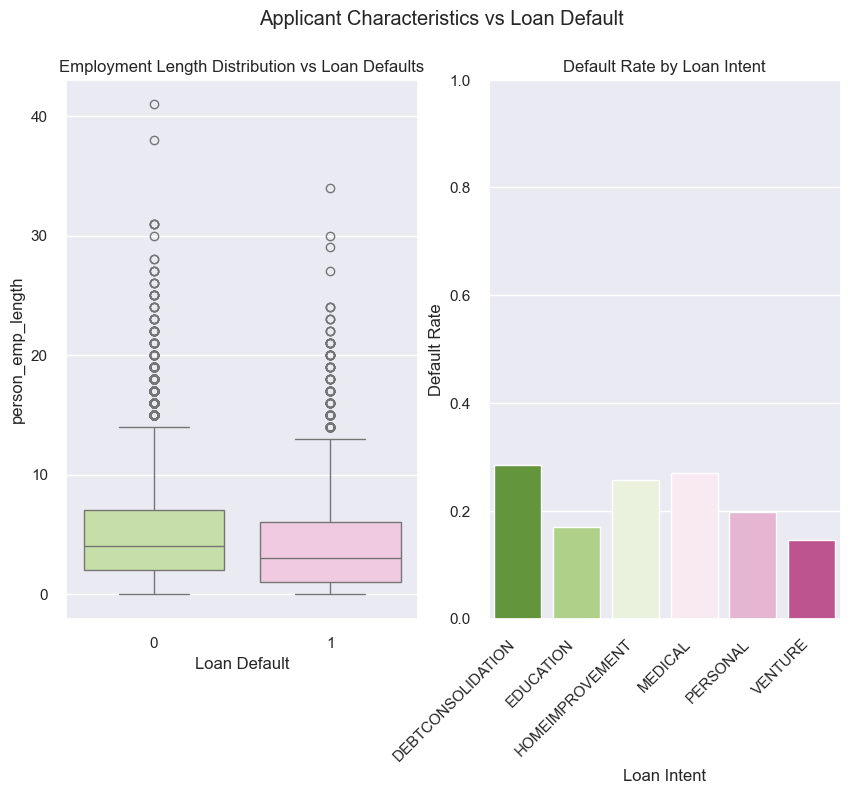

In [33]:
fig,axes = plt.subplots(1,2,figsize= (10,7))
fig.suptitle('Applicant Characteristics vs Loan Default')

#Distribution of Employment length between people who defaulted and did not 
sns.boxplot(
    data=credit_df,
    x='loan_status',
    y='person_emp_length',
    palette='PiYG_r',
    ax= axes[0]
)
axes[0].set_title("Employment Length Distribution vs Loan Defaults")
axes[0].set_xlabel("Loan Default")

#How defualt rates vary across different loan purposes
default_rate = (credit_df.groupby("loan_intent")["loan_status"].mean().rename("default_rate"))
default_rate = default_rate.reset_index()

sns.barplot(
    data=default_rate,
    x="loan_intent",
    y="default_rate",
    palette= 'PiYG_r',
    ax= axes[1]
)
axes[1].set_title("Default Rate by Loan Intent")
axes[1].set_xlabel("Loan Intent")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("Default Rate")
axes[1].set_ylim(0, 1)  

plt.show()

##### Target Variable Correlations

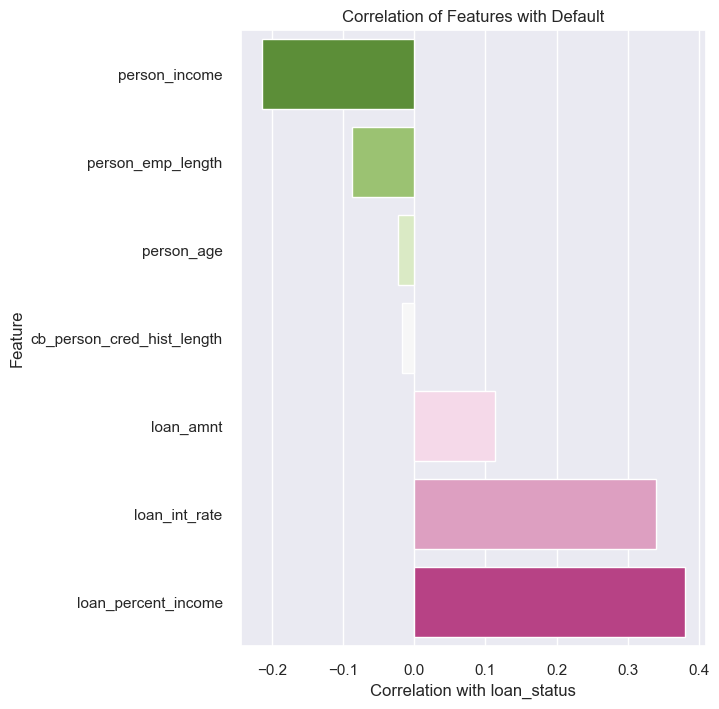

In [34]:
corr = credit_df.corr(numeric_only=True)['loan_status'].sort_values()

corr = corr.drop('loan_status')

plt.figure(figsize=(6,8))
sns.barplot(
    x=corr.values,
    y=corr.index,
    orient='h',
    palette='PiYG_r'
)
plt.title("Correlation of Features with Default")
plt.xlabel("Correlation with loan_status")
plt.ylabel("Feature")

plt.show()


#### 2.3 Correlation Analysis

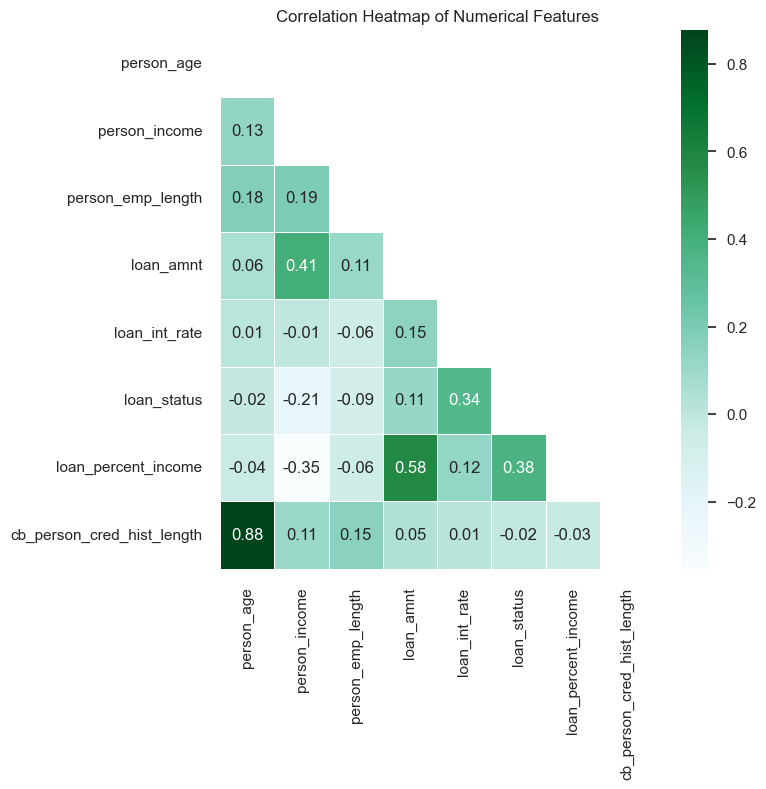

In [35]:
corr = credit_df.select_dtypes(include=np.number).corr()

mask = np.zeros_like(corr) 
mask[np.triu_indices_from(mask)] = True 

plt.figure(figsize=(7, 7))
with sns.axes_style("white"):
    ax = sns.heatmap(
        corr, 
        mask=mask, 
        cmap='BuGn', 
        annot=True, 
        fmt='.2f', 
        linewidths=0.5
        )
    
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

#### 2.4 Key Insights

| Theme | Finding | Business Implication |
|---|---|---|
| Class Imbalance | 78% non-default vs 22% default | Accuracy alone would be misleading |
| Income | Right-skewed, defaulters earn significantly less | Lower income applicants represent higher risk |
| Loan-to-Income | Defaulters carry disproportionately high loan-to-income ratios | Key affordability signal for lenders |
| Loan Grade | Near-100% default rate at Grade G, <10% at Grade A | Grade is a strong indicator for risk|
| Historical Default | 38% default rate for applicants with prior default on file vs 18% without | Prior default history is a significant red flag |
| Interest Rate | Positive correlation (0.34) with default | Higher rates reflect higher risk |
| Multicollinearity | Age and credit history length correlated at 0.88 | Likely redundant features  |

## Section 3 — Feature Engineering

#### 3.1 Encoding 

In [36]:
#Encoding Binary Features (Default On File)
credit_df['cb_person_default_on_file'] = (credit_df['cb_person_default_on_file'].str.strip().str.upper().map({'Y': 1, 'N': 0}))

credit_df['cb_person_default_on_file'].unique()

array([0, 1])

In [37]:
#One Hot Encoding Categorical Features ('loan_grade', 'loan_intent', 'person_home_ownership')
credit_df = pd.get_dummies(
    credit_df,
    columns=['loan_grade', 'loan_intent', 'person_home_ownership'],
    drop_first=True
)

## Section 4 — Machine Learning Algorithm

#### 4.1 Train / Test Split


In [38]:
X = credit_df.drop('loan_status', axis=1)
y = credit_df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.30,random_state=42,stratify=y)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (19946, 22) (19946,)
Test: (8549, 22) (8549,)


In [39]:
numeric_cols = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length'
]

scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])

X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])


#### 4.2 Baseline — Logistic Regression


In [40]:
base_model= LogisticRegression(
    max_iter= 1000,
    class_weight= 'balanced',
)
base_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
y_pred = base_model.predict(X_test)
y_proba_base = base_model.predict_proba(X_test)[:, 1]

##### Base Model Evaluation

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.83      0.88      6693
           1       0.55      0.78      0.65      1856

    accuracy                           0.82      8549
   macro avg       0.74      0.80      0.76      8549
weighted avg       0.85      0.82      0.83      8549



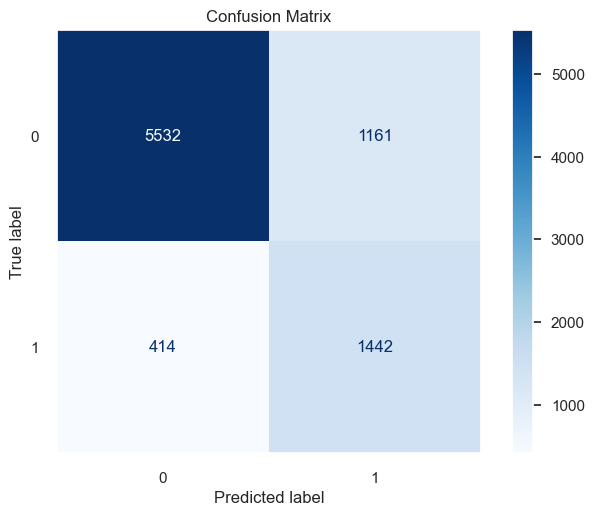

In [43]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

ROC-AUC: 0.8709


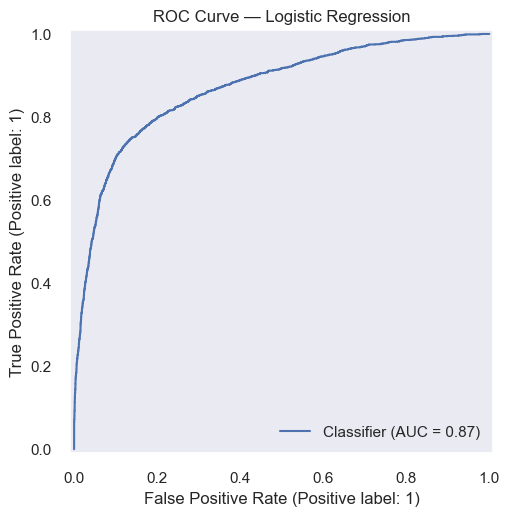

In [44]:
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_base):.4f}")

RocCurveDisplay.from_predictions(y_test, y_proba_base)
plt.title("ROC Curve — Logistic Regression")
plt.grid(False)
plt.show()

#### 4.3 XGBoost Classifier

In [45]:
y_train.value_counts()

loan_status
0    15615
1     4331
Name: count, dtype: int64

In [46]:
xgb_model = XGBClassifier(
    scale_pos_weight=3.6,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [47]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

##### XGBoost Evaluation

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      6693
           1       0.81      0.80      0.80      1856

    accuracy                           0.92      8549
   macro avg       0.88      0.87      0.87      8549
weighted avg       0.91      0.92      0.91      8549



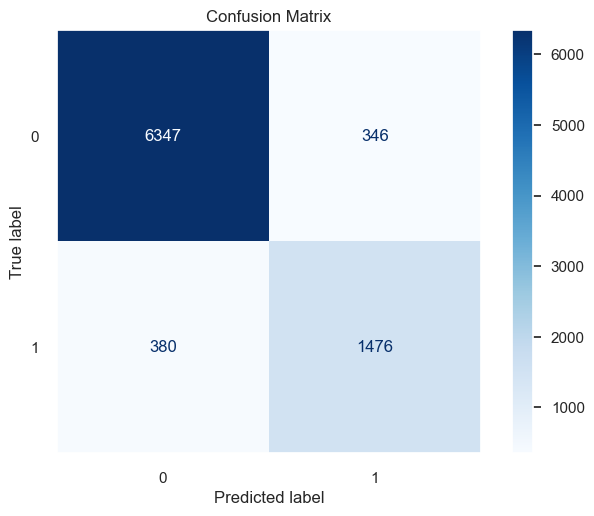

In [49]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

ROC-AUC: 0.9461


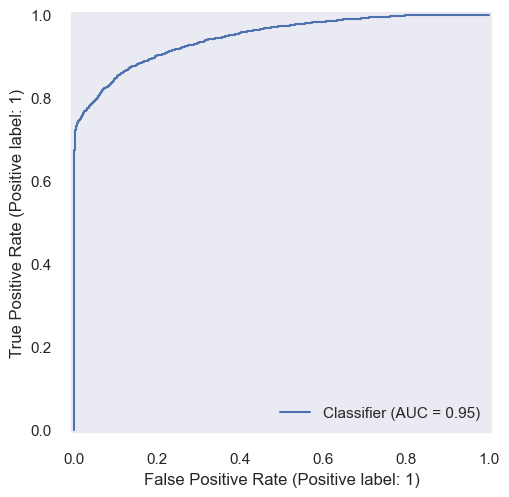

In [50]:
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.grid(False)
plt.show()

#### 4.4 Cross Validation and Hyperparameter Tuning

In [51]:
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [52]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

In [53]:
grid = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=3.6,
        eval_metric='logloss',
        random_state=42
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=kfold, 
    n_jobs=-1
)

In [54]:
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}


#### 4.5 Final Classifier

In [55]:
final_xgb = XGBClassifier(
    scale_pos_weight=3.6,
    eval_metric='logloss',
    learning_rate=0.1,
    max_depth=5,
    n_estimators=300,
    subsample=1.0,
    random_state=42
)

final_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [56]:
y_pred = final_xgb.predict(X_test)
y_proba_tuned = final_xgb.predict_proba(X_test)[:, 1]

##### Tuned XGBoost Evaluation

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      6693
           1       0.81      0.80      0.80      1856

    accuracy                           0.92      8549
   macro avg       0.88      0.87      0.88      8549
weighted avg       0.92      0.92      0.92      8549



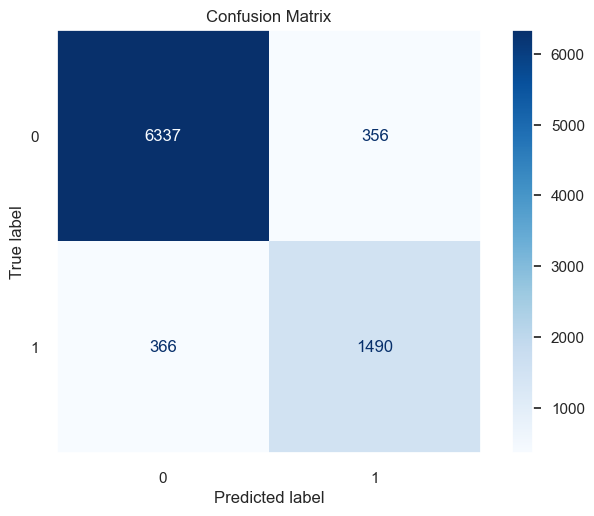

In [58]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

ROC-AUC: 0.9468


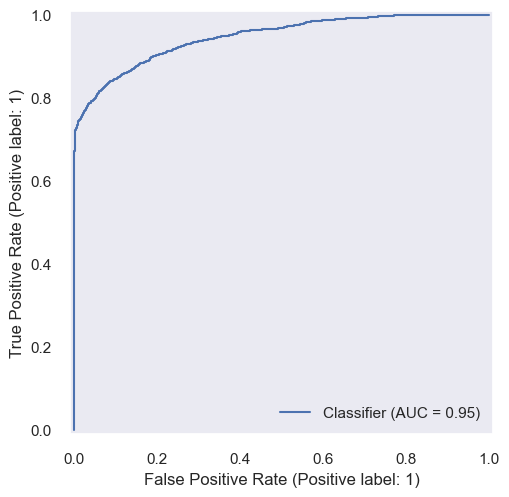

In [59]:
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}")
RocCurveDisplay.from_predictions(y_test, y_proba_tuned)
plt.grid(False)
plt.show()

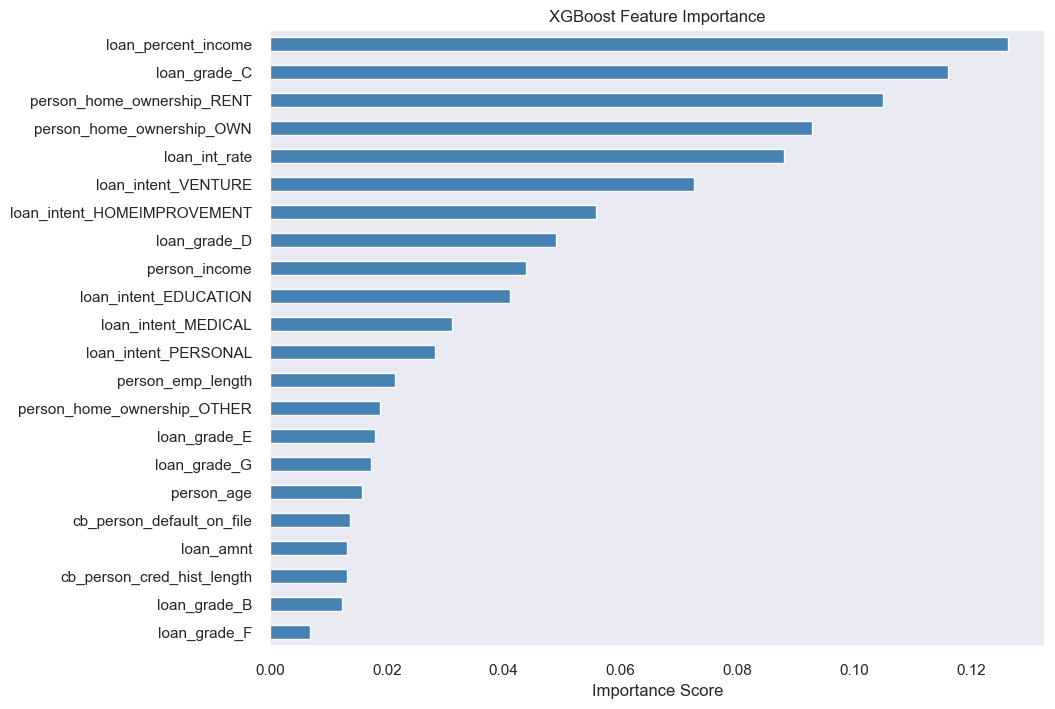

In [60]:
feat_imp = pd.Series(final_xgb.feature_importances_,index=X.columns).sort_values(ascending=True)

feat_imp.plot(
    kind='barh', 
    figsize=(10, 8), 
    color='steelblue')

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.grid(False)
plt.show()

## Section 5 — Evaluation

In [61]:
results = {
    'Model': ['Logistic Regression', 'XGBoost (Default)', 'XGBoost (Tuned)'],
    'Accuracy': [0.82, 0.92, 0.92],
    'Precision (Class 1)': [0.55, 0.81, 0.81],
    'Recall (Class 1)': [0.78, 0.80, 0.80],
    'F1 (Class 1)': [0.65, 0.80, 0.80],
    'ROC-AUC': [0.87, 0.9461, 0.9468]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1 (Class 1),ROC-AUC
0,Logistic Regression,0.82,0.55,0.78,0.65,0.8700
1,XGBoost (Default),0.92,0.81,0.80,0.80,0.9461
2,XGBoost (Tuned),0.92,0.81,0.80,0.80,0.9468


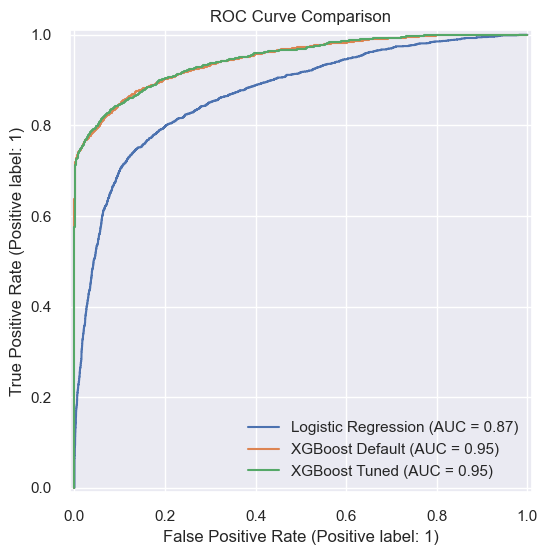

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_proba_base, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba,name='XGBoost Default', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_tuned,name='XGBoost Tuned', ax=ax)

plt.title('ROC Curve Comparison')
plt.grid(True)
plt.show()

The tuned XGBoost model achieved 92% accuracy and ROC-AUC of 0.95, a 
significant improvement over the logistic regression baseline (0.87). 
However there was a marginal difference between initial and tuned XGBoost (0.9461 vs 0.9468) suggesting the original XGBoost was well-optimised to the dataset. 

## Section 6 — Business Recommendations

**1.Prioritise loan‑to‑income checks**
This was the strongest predictor of loan default. Applicants borrowing more than 30-40% of their income should be assessed more closely to ensure they can confidently repay. 

**2. Home Ownership as a sign of stability**
Renters appeared to be higher-risk and that can help inform how confident to be about an applicants liklihood to default.

**3. Venture as loan intent to be monitored**
This loan intent catergory showed the greates risk of deefault, implementing extra checks might be useful.